In [26]:
#Import libraries.
import rapids_singlecell as rsc
import scanpy as sc
import cupy as cp
import anndata
import numpy as np

In [27]:
#Allow oversubscription of memory.
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [28]:
#Read in h5ad (usually converted with SeuratDisk) and store raw counts in adata.raw.
adata = sc.read("seurat_data_nonimmune.h5ad")
adata.raw = adata

In [29]:
adata

AnnData object with n_obs × n_vars = 540041 × 476
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'num.blank', 'TMA', 'Sample', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'Lineage'
    var: 'features'
    obsm: 'X_pca', 'X_sp', 'X_umap'

In [30]:
#Send adata object to GPU.
rsc.get.anndata_to_GPU(adata)

In [31]:
#Log transform and scale data. NOTE: If you want to normalize the data, you will need to add the line yourself.
rsc.pp.log1p(adata)
rsc.pp.scale(adata)

In [32]:
#Run PCA.
rsc.tl.pca(adata, n_comps=100)

In [33]:
#Send adata object back to CPU.
rsc.get.anndata_to_CPU(adata)

In [34]:
#Neighbours and umap.
rsc.pp.neighbors(adata, n_neighbors=30, n_pcs=20)
rsc.tl.umap(adata)

In [35]:
#Leiden clustering, add resolutions as needed.
rsc.tl.leiden(adata, resolution=0.5, key_added="leiden_0.5")
rsc.tl.leiden(adata, resolution=1.0, key_added="leiden_1.0")
rsc.tl.leiden(adata, resolution=1.5, key_added="leiden_1.5")
rsc.tl.leiden(adata, resolution=2.0, key_added="leiden_2.0")

... storing 'orig.ident' as categorical
... storing 'segmentation_method' as categorical
... storing 'Sample' as categorical
... storing 'Lineage' as categorical


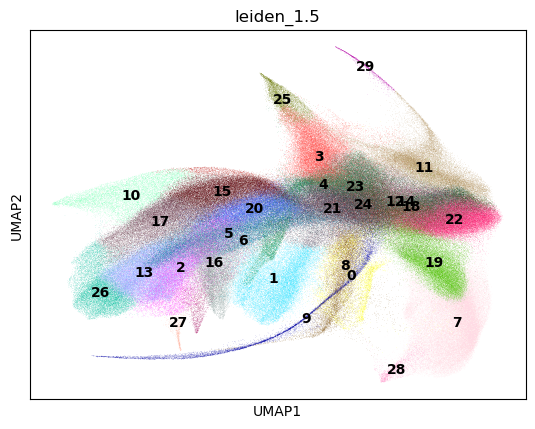

In [36]:
#Plot umap, change color argument to show different resolutions.
sc.pl.umap(adata, color=["leiden_1.5"], legend_loc="on data")

In [37]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,...,nucleus_count,segmentation_method,num.blank,TMA,Sample,leiden_0.5,leiden_1.0,leiden_1.5,leiden_2.0,Lineage
TMA1_0069754_aaaaaklo-1,SeuratProject,17.0,15,TMA1_0069754_aaaaaklo-1,6974.345703,2858.790039,17.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,5,16,14,18,TumorStroma
TMA1_0069754_aaaadlng-1,SeuratProject,188.0,67,TMA1_0069754_aaaadlng-1,7123.416016,2844.681396,188.0,0.0,0.0,0.0,...,2,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8,5,7,30,TumorStroma
TMA1_0069754_aaaaffeg-1,SeuratProject,83.0,42,TMA1_0069754_aaaaffeg-1,7156.845703,2834.984619,83.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8,5,7,3,TumorStroma
TMA1_0069754_aaaahhme-1,SeuratProject,63.0,45,TMA1_0069754_aaaahhme-1,7141.638672,2729.656738,64.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,2,9,9,11,TumorStroma
TMA1_0069754_aaaahphm-1,SeuratProject,160.0,58,TMA1_0069754_aaaahphm-1,7125.770996,2771.934082,160.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8,5,7,30,TumorStroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA1_0069754_oimdmokb-1,SeuratProject,30.0,24,TMA1_0069754_oimdmokb-1,337.097809,20499.583984,30.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,0,7,23,25,TumorStroma
TMA1_0069754_oimdopgm-1,SeuratProject,11.0,10,TMA1_0069754_oimdopgm-1,137.100937,20919.929688,11.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,11,19,21,26,TumorStroma
TMA1_0069754_oimdpdag-1,SeuratProject,18.0,16,TMA1_0069754_oimdpdag-1,299.259094,20940.744141,18.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,4,3,12,9,TumorStroma
TMA1_0069754_oimedcek-1,SeuratProject,18.0,13,TMA1_0069754_oimedcek-1,442.865204,20803.378906,18.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,0,15,23,25,TumorStroma


In [38]:
adata.obs['total_counts']

TMA1_0069754_aaaaaklo-1     17.0
TMA1_0069754_aaaadlng-1    188.0
TMA1_0069754_aaaaffeg-1     83.0
TMA1_0069754_aaaahhme-1     64.0
TMA1_0069754_aaaahphm-1    160.0
                           ...  
TMA1_0069754_oimdmokb-1     30.0
TMA1_0069754_oimdopgm-1     11.0
TMA1_0069754_oimdpdag-1     18.0
TMA1_0069754_oimedcek-1     18.0
TMA1_0069754_oimeeffd-1     30.0
Name: total_counts, Length: 540041, dtype: float64

In [39]:
adata.obs["transcript_counts"] = adata.obs["transcript_counts"].astype('float64')
adata.obs["control_probe_counts"] = adata.obs["control_probe_counts"].astype('float64')
adata.obs["genomic_control_counts"] = adata.obs["genomic_control_counts"].astype('float64')

adata.obs["control_codeword_counts"] = adata.obs["control_codeword_counts"].astype('float64')
adata.obs["unassigned_codeword_counts"] = adata.obs["unassigned_codeword_counts"].astype('float64')
adata.obs["deprecated_codeword_counts"] = adata.obs["deprecated_codeword_counts"].astype('float64')
adata.obs["total_counts"] = adata.obs["total_counts"].astype('float64')

adata.obs["leiden_0.5"] = adata.obs["leiden_0.5"].astype('float64')
adata.obs["leiden_1.0"] = adata.obs["leiden_1.0"].astype('float64')
adata.obs["leiden_1.5"] = adata.obs["leiden_1.5"].astype('float64')
adata.obs["leiden_2.0"] = adata.obs["leiden_2.0"].astype('float64')

In [40]:
#Put log back in adata.X. Write adata to h5ad file. Change file name as needed.
adata.X = sc.pp.log1p(adata.raw.X, copy=True)
adata.write_h5ad("cell_nonimmune.h5ad")

In [41]:
#adata.obs.to_csv("anndata_obs.csv")

In [42]:
#adata.raw.X.to_csv("anndata_raw.csv")

In [43]:
# Convert to a dense NumPy array
raw_counts = adata.raw.X.toarray()

# Save the dense array to a CSV file
np.savetxt("cell_nonimmune_raw_counts.csv", raw_counts, delimiter=",")

In [44]:
log1p_counts = adata.X.toarray()
np.savetxt("cell_nonimmune_log1p_counts.csv", log1p_counts, delimiter=",")

In [45]:
#reduced_adata = anndata.AnnData()
#reduced_adata.obsm['pca'] = adata.obsm['X_pca']
#reduced_adata.obsm['umap'] = adata.obsm['X_umap']
#reduced_adata.obs_names = adata.obs_names

In [46]:
adata.obsm['X_pca']

array([[-3.6422675e+00,  4.6639547e-01,  1.6576913e-01, ...,
         7.4164408e-01, -4.4343781e-01,  8.9111727e-01],
       [ 4.2301588e+00,  1.2480208e+01,  5.5135612e+00, ...,
         3.1842176e-02,  8.7326276e-01,  2.7366236e-02],
       [ 8.5453576e-01,  4.8433166e+00,  2.1080608e+00, ...,
         8.6613780e-01, -9.5763855e-02,  2.8890436e+00],
       ...,
       [-2.7948914e+00, -1.7431310e+00, -5.0408441e-01, ...,
        -1.1314339e-01, -1.5449244e-01,  3.5748620e-02],
       [-3.0609221e+00, -1.1462015e+00,  5.6692999e-02, ...,
         8.4006519e-04,  6.6577390e-02,  6.9477819e-02],
       [-2.2396770e+00, -1.0963459e+00, -2.1846835e-01, ...,
        -1.4506339e-01,  5.5409783e-01,  7.8027159e-01]],
      shape=(540041, 100), dtype=float32)

In [47]:
pcs = adata.obsm['X_pca']
np.savetxt("cell_nonimmune_pcs.csv", pcs, delimiter=",")

In [48]:
umap = adata.obsm['X_umap']
np.savetxt("cell_nonimmune_umap.csv", umap, delimiter=",")

In [49]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,...,nucleus_count,segmentation_method,num.blank,TMA,Sample,leiden_0.5,leiden_1.0,leiden_1.5,leiden_2.0,Lineage
TMA1_0069754_aaaaaklo-1,SeuratProject,17.0,15,TMA1_0069754_aaaaaklo-1,6974.345703,2858.790039,17.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,5.0,16.0,14.0,18.0,TumorStroma
TMA1_0069754_aaaadlng-1,SeuratProject,188.0,67,TMA1_0069754_aaaadlng-1,7123.416016,2844.681396,188.0,0.0,0.0,0.0,...,2,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8.0,5.0,7.0,30.0,TumorStroma
TMA1_0069754_aaaaffeg-1,SeuratProject,83.0,42,TMA1_0069754_aaaaffeg-1,7156.845703,2834.984619,83.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8.0,5.0,7.0,3.0,TumorStroma
TMA1_0069754_aaaahhme-1,SeuratProject,63.0,45,TMA1_0069754_aaaahhme-1,7141.638672,2729.656738,64.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,2.0,9.0,9.0,11.0,TumorStroma
TMA1_0069754_aaaahphm-1,SeuratProject,160.0,58,TMA1_0069754_aaaahphm-1,7125.770996,2771.934082,160.0,0.0,0.0,0.0,...,1,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,0.0,0,UPN109-E1,8.0,5.0,7.0,30.0,TumorStroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA1_0069754_oimdmokb-1,SeuratProject,30.0,24,TMA1_0069754_oimdmokb-1,337.097809,20499.583984,30.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,0.0,7.0,23.0,25.0,TumorStroma
TMA1_0069754_oimdopgm-1,SeuratProject,11.0,10,TMA1_0069754_oimdopgm-1,137.100937,20919.929688,11.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,11.0,19.0,21.0,26.0,TumorStroma
TMA1_0069754_oimdpdag-1,SeuratProject,18.0,16,TMA1_0069754_oimdpdag-1,299.259094,20940.744141,18.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,4.0,3.0,12.0,9.0,TumorStroma
TMA1_0069754_oimedcek-1,SeuratProject,18.0,13,TMA1_0069754_oimedcek-1,442.865204,20803.378906,18.0,0.0,0.0,0.0,...,1,Segmented by nucleus expansion of 5.0µm,0.0,0,UPN141-B1.1,0.0,15.0,23.0,25.0,TumorStroma


In [50]:
#obs = adata.obs.toarray()
#np.savetxt("obs.csv", adata.obs, delimiter=",")
adata.obs.to_csv("cell_nonimmune_obs.csv")